# Custom Latitude Distributions

The GP kernel is an average of single-latitude contributions weighted by how spots are distributed across the stellar surface:

$$K(\tau) = \sigma_k^2\, R_\Gamma(\tau) \int_{-\pi/2}^{\pi/2} p(\phi)\left[|c_0(\phi)|^2 + 2\sum_{n=1}^{N} |c_n(\phi)|^2 \cos(n\,\omega_0(\phi)\,\tau)\right] d\phi$$

where $p(\phi)$ is the **latitude probability density** and $\phi \in [-\pi/2, \pi/2]$ (south pole to north pole).

By default the distribution is **uniform** — spots can emerge anywhere. Real stars, however, concentrate spot activity at preferred latitudes:

| Star type | Typical spot distribution |
|-----------|---------------------------|
| Sun-like  | Two activity bands ±15–30° (butterfly diagram) |
| Young active | Polar caps above ±60° |
| Equatorial | Belt around ±10° |

The `lat_dist` parameter of `kernel()`, `kernel_solid_body()`, and `compute_psd()` accepts any callable `p(phi) -> float` to encode these priors. This notebook shows how to define and use several common distributions.

In [1]:
import sys
sys.path.append("../..")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from src_numpy.analytic_kernel import AnalyticKernel

## 1. Shared kernel parameters

All examples below use the same stellar and spot parameters so that differences in the kernel are due solely to the latitude distribution.

In [3]:
hparam = dict(
    peq=5.0,       # equatorial rotation period [days]
    kappa=0.3,     # differential rotation shear
    inc=np.pi/3,   # inclination 60°
    lspot=10.0,    # spot lifetime [days]
    tau=3.0,       # rise/decay timescale [days]
    sigma_k=0.01,  # kernel amplitude
)

ak = AnalyticKernel(hparam, n_harmonics=3, n_lat=64)

tlags = np.linspace(0, 30, 500)

## 2. Define latitude distributions

Each distribution is a plain Python function of latitude $\phi$ in **radians**. It does not need to be normalized — the kernel automatically normalizes by $\int p(\phi)\,d\phi$.

In [4]:
# --- 1. Uniform (default behavior) -------------------------------------------
def uniform(phi):
    """Spots uniformly distributed across all latitudes."""
    return 1.0


# --- 2. Equatorial belt ----------------------------------------------------------
def equatorial_belt(phi, phi0=np.deg2rad(10), sigma=np.deg2rad(8)):
    """Spots concentrated in a single belt around the equator."""
    return np.exp(-phi**2 / (2 * sigma**2))


# --- 3. Butterfly diagram (two symmetric activity bands) -----------------------
def butterfly(phi, phi0=np.deg2rad(20), sigma=np.deg2rad(8)):
    """
    Two Gaussian bands symmetric about the equator, mimicking the
    solar butterfly diagram.  phi0 sets the band latitude.
    """
    return (
        np.exp(-(phi - phi0)**2 / (2 * sigma**2))
        + np.exp(-(phi + phi0)**2 / (2 * sigma**2))
    )


# --- 4. Polar cap ---------------------------------------------------------------
def polar_cap(phi, phi0=np.deg2rad(60), sigma=np.deg2rad(15)):
    """
    Spots concentrated near both poles, as seen on young active stars.
    """
    return (
        np.exp(-(phi - np.pi/2)**2 / (2 * sigma**2))
        + np.exp(-(phi + np.pi/2)**2 / (2 * sigma**2))
    )


distributions = {
    "Uniform (default)": (uniform,      "C0", "-"),
    "Equatorial belt":   (equatorial_belt, "C1", "--"),
    "Butterfly diagram": (butterfly,     "C2", "-."),
    "Polar cap":         (polar_cap,     "C3", ":"),
}

## 3. Visualize the distributions

It is useful to plot $p(\phi)$ to confirm the distributions look as intended before passing them to the kernel.

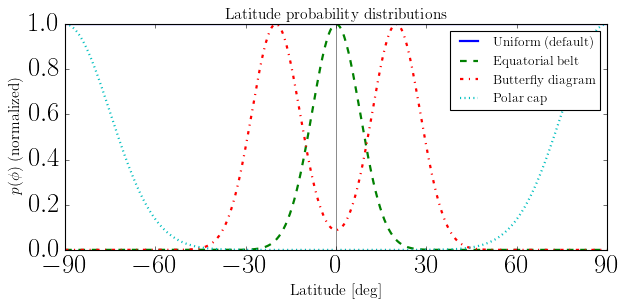

In [6]:
phi_deg = np.linspace(-90, 90, 500)
phi_rad = np.deg2rad(phi_deg)

fig, ax = plt.subplots(figsize=(8, 4))

for label, (dist, color, ls) in distributions.items():
    p = np.array([dist(p) for p in phi_rad])
    p /= p.max()   # normalize to 1 for visual comparison
    ax.plot(phi_deg, p, color=color, ls=ls, lw=2, label=label)

ax.axvline(0, color="gray", lw=0.8, ls="-")
ax.set_xlabel("Latitude [deg]", fontsize=14)
ax.set_ylabel("$p(\\phi)$ (normalized)", fontsize=14)
ax.set_title("Latitude probability distributions", fontsize=14)
ax.set_xticks(np.arange(-90, 91, 30))
ax.set_xlim(-90, 90)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 4. Compute kernels with each distribution

Pass any distribution to `kernel()` via the `lat_dist` keyword.  Passing `None` (or omitting it) uses the uniform default.

In [7]:
kernels = {}

for label, (dist, color, ls) in distributions.items():
    K = ak.kernel(tlags, lat_dist=dist)
    kernels[label] = K
    print(f"{label:<22}  K(0) = {K[0]:.6f}")

Uniform (default)       K(0) = 0.000181
Equatorial belt         K(0) = 0.000208
Butterfly diagram       K(0) = 0.000200
Polar cap               K(0) = 0.000176


## 5. Compare kernel shapes

Different latitude distributions shift power between harmonics and broaden or sharpen the rotational peaks.  With differential rotation (`kappa > 0`) the latitude distribution also controls the effective spread of rotation periods.

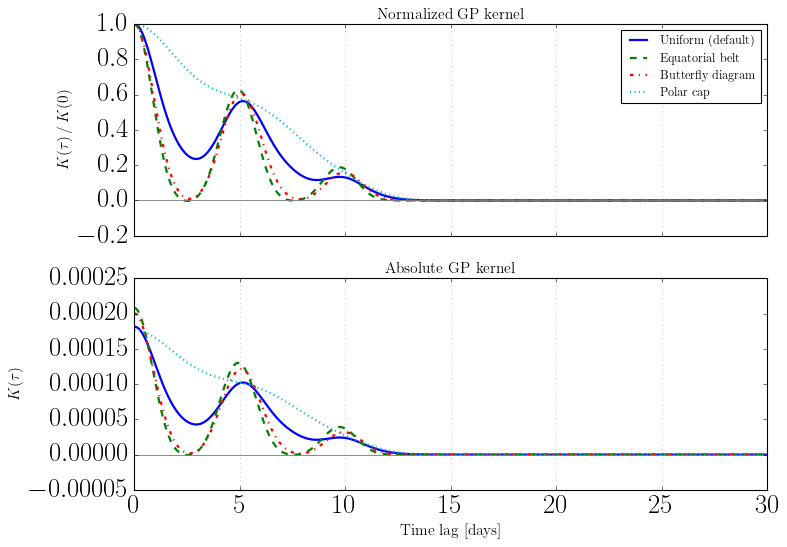

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Top panel: normalized kernel
ax = axes[0]
for label, (dist, color, ls) in distributions.items():
    K = kernels[label]
    ax.plot(tlags, K / K[0], color=color, ls=ls, lw=2, label=label)

for ii in range(1, 7):
    ax.axvline(ii * hparam["peq"], color="gray", ls=":", alpha=0.4)
ax.axhline(0, color="gray", lw=0.8)
ax.set_ylabel(r"$K(\tau)\,/\,K(0)$", fontsize=14)
ax.set_title("Normalized GP kernel", fontsize=14)
ax.legend(fontsize=11)

# Bottom panel: absolute scale
ax = axes[1]
for label, (dist, color, ls) in distributions.items():
    K = kernels[label]
    ax.plot(tlags, K, color=color, ls=ls, lw=2, label=label)

for ii in range(1, 7):
    ax.axvline(ii * hparam["peq"], color="gray", ls=":", alpha=0.4)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("Time lag [days]", fontsize=14)
ax.set_ylabel(r"$K(\tau)$", fontsize=14)
ax.set_title("Absolute GP kernel", fontsize=14)

plt.tight_layout()
plt.show()

## 6. Effect on the power spectral density

The `compute_psd()` method also accepts `lat_dist`, so you can directly compare the PSD for each scenario.  The latitude distribution determines how much power falls in each harmonic of the rotation frequency $f_n = n / P_{\rm eq}(\phi)$.

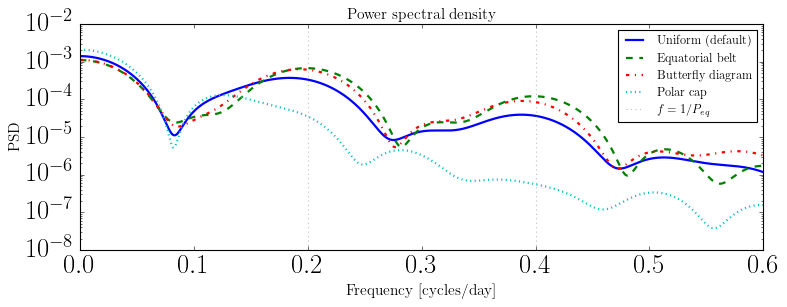

In [9]:
omega = np.linspace(0, 6 * np.pi / hparam["peq"], 2000)

fig, ax = plt.subplots(figsize=(10, 4))

for label, (dist, color, ls) in distributions.items():
    freq, psd = ak.compute_psd(omega, lat_dist=dist)
    ax.semilogy(freq, psd, color=color, ls=ls, lw=2, label=label)

for ii in range(1, 4):
    ax.axvline(ii / hparam["peq"], color="gray", ls=":", alpha=0.5,
               label=f"$f={ii}/P_{{eq}}$" if ii == 1 else None)

ax.set_xlabel("Frequency [cycles/day]", fontsize=14)
ax.set_ylabel("PSD", fontsize=14)
ax.set_title("Power spectral density", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 7. Latitude distributions and differential rotation

With differential rotation (`kappa > 0`) each latitude rotates at a different period:

$$P(\phi) = \frac{P_{\rm eq}}{1 - \kappa \sin^2\phi}$$

The latitude distribution therefore controls the **effective period spread** sampled by the GP kernel.  A narrow equatorial belt probes only the fast equatorial period; a polar cap probes the slow polar periods; a butterfly diagram samples intermediate values.

The cell below shows this explicitly by plotting the effective rotation period weighted by each distribution.

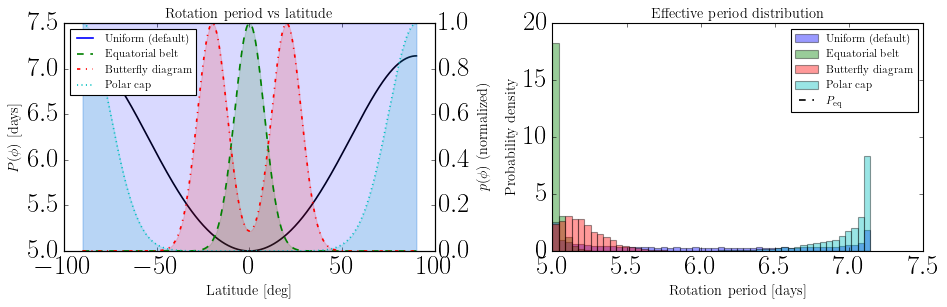

In [10]:
phi_grid = np.linspace(-np.pi/2, np.pi/2, 512)
P_phi = hparam["peq"] / (1 - hparam["kappa"] * np.sin(phi_grid)**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax2 = ax.twinx()
ax.plot(np.rad2deg(phi_grid), P_phi, "k", lw=1.5, label="$P(\\phi)$")
for label, (dist, color, ls) in distributions.items():
    p = np.array([dist(p) for p in phi_grid])
    p /= p.max()
    ax2.fill_between(np.rad2deg(phi_grid), p, alpha=0.15, color=color)
    ax2.plot(np.rad2deg(phi_grid), p, color=color, ls=ls, lw=1.5, label=label)
ax.set_xlabel("Latitude [deg]", fontsize=13)
ax.set_ylabel("$P(\\phi)$ [days]", fontsize=13)
ax2.set_ylabel("$p(\\phi)$ (normalized)", fontsize=13)
ax.set_title("Rotation period vs latitude", fontsize=13)
ax2.legend(fontsize=10, loc="upper left")

# Right panel: distribution of periods sampled by each lat_dist
ax = axes[1]
for label, (dist, color, ls) in distributions.items():
    p = np.array([dist(p) for p in phi_grid])
    norm = np.trapezoid(p, phi_grid)
    # histogram of periods weighted by p(phi)
    ax.hist(P_phi, bins=50, weights=p / norm,
            color=color, alpha=0.4, density=True, label=label)

ax.axvline(hparam["peq"], color="k", ls="--", lw=1.5, label="$P_{\\rm eq}$")
ax.set_xlabel("Rotation period [days]", fontsize=13)
ax.set_ylabel("Probability density", fontsize=13)
ax.set_title("Effective period distribution", fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 8. Using a custom `lat_dist` with `GPSolver`

`GPSolver` builds an `AnalyticKernel` internally and calls `kernel.kernel(tau)` without a `lat_dist` argument (i.e. it uses the uniform default).  The cleanest way to inject a fixed latitude distribution is to subclass `AnalyticKernel` and override `kernel()` to bind your chosen distribution, then swap the internal kernel object after construction.

In [11]:
from src_numpy.starspot import LightcurveModel
from src_numpy.gp_solver import GPSolver
from src_numpy.analytic_kernel import AnalyticKernel

# Generate synthetic data with spots confined to activity bands
np.random.seed(0)

theta_true = dict(
    peq=5.0, kappa=0.3, inc=np.pi/3,
    nspot=40, lspot=10.0, tau=3.0,
    alpha_max=0.05, fspot=0.,
    lat=[-np.deg2rad(35), np.deg2rad(35)],
    long=[0, 2*np.pi],
)

lc = LightcurveModel(**theta_true, tsim=100, tsamp=0.5)
tobs = lc.t
flux = lc.flux
flux_err = np.abs(np.random.normal(0, 0.2 * np.std(flux), flux.shape))


# --- Helper: subclass that fixes lat_dist at construction time ---------------
def make_fixed_lat_dist_kernel(lat_dist_fn):
    """Return an AnalyticKernel subclass with lat_dist baked in."""

    class FixedLatDistKernel(AnalyticKernel):
        def kernel(self, lag, lat_dist=None):
            return super().kernel(lag, lat_dist=lat_dist_fn)

    return FixedLatDistKernel


# Hyperparameters for the GP kernel
hparam_gp = dict(peq=5.0, kappa=0.3, inc=np.pi/3, lspot=10.0, tau=3.0,
                 nspot=40, alpha_max=0.05, fspot=0.)

# Uniform distribution (default)
gp_uniform = GPSolver(tobs, flux, flux_err, hparam_gp)

# Butterfly distribution: swap in our custom kernel then rebuild the covariance
ButterflyKernel = make_fixed_lat_dist_kernel(butterfly)
gp_butterfly = GPSolver(tobs, flux, flux_err, hparam_gp)
gp_butterfly.kernel = ButterflyKernel(hparam_gp, n_lat=128)
gp_butterfly._build_covariance()

ll_uniform   = gp_uniform.log_likelihood()
ll_butterfly = gp_butterfly.log_likelihood()

print(f"log-likelihood (uniform):   {ll_uniform:.2f}")
print(f"log-likelihood (butterfly): {ll_butterfly:.2f}")

log-likelihood (uniform):   1085.63
log-likelihood (butterfly): 1062.26


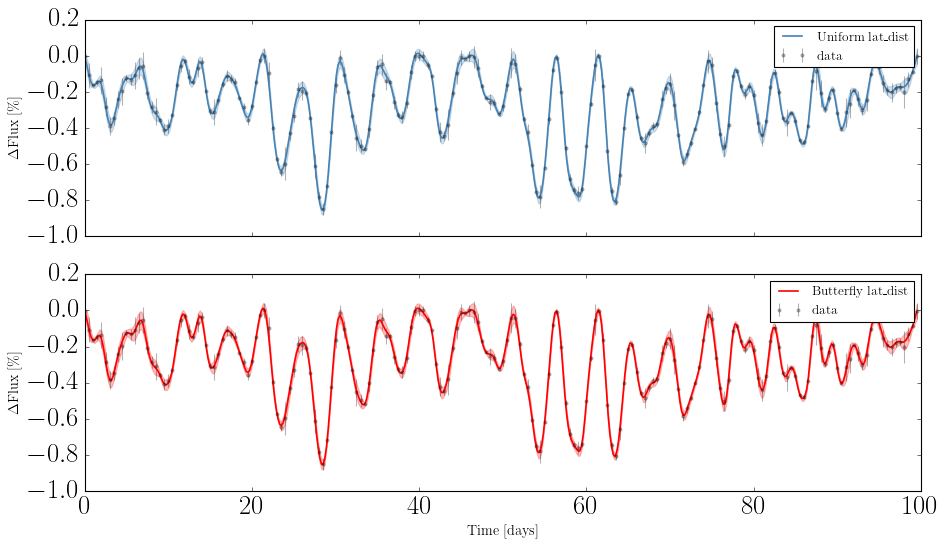

In [13]:
xpred = np.linspace(tobs.min(), tobs.max(), 500)

mu_uni,  var_uni  = gp_uniform.predict(xpred, return_cov=False)
mu_but,  var_but  = gp_butterfly.predict(xpred, return_cov=False)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, mu, var, label, color in zip(
        axes,
        [mu_uni, mu_but],
        [var_uni, var_but],
        ["Uniform lat_dist", "Butterfly lat_dist"],
        ["steelblue", "C2"]):
    std = np.sqrt(np.asarray(var))
    ax.errorbar(tobs, flux * 100 - 100, yerr=flux_err * 100,
                fmt=".k", capsize=0, alpha=0.3, label="data")
    ax.plot(xpred, np.asarray(mu) * 100 - 100, color=color, lw=1.5, label=label)
    ax.fill_between(xpred,
                    (np.asarray(mu) - std) * 100 - 100,
                    (np.asarray(mu) + std) * 100 - 100,
                    alpha=0.25, color=color)
    ax.set_ylabel(r"$\Delta$Flux [\%]", fontsize=13)
    ax.legend(fontsize=12)

axes[-1].set_xlabel("Time [days]", fontsize=13)
plt.tight_layout()
plt.show()

## Tips:

**Integration accuracy** — The default trapezoid rule with `n_lat=64` is sufficient for broad distributions. For sharply peaked distributions (e.g. a narrow equatorial belt with $\sigma < 5°$) increase `n_lat` or switch to Gauss-Legendre quadrature:

```python
ak = AnalyticKernel(hparam, n_lat=256, quadrature="gauss-legendre")
```

**Units** — Latitudes are always in **radians** inside `lat_dist`. Convert degrees with `np.deg2rad()`.

**Normalization** — `lat_dist` does not need to integrate to one. The kernel normalizes internally by $\int p(\phi)\,d\phi$, so scaling $p$ by a constant has no effect on the kernel shape.

**JAX backend** — The same `lat_dist` callable works identically with `src_jax`. However, because `lat_dist` is evaluated in Python before JIT-compilation, changing it requires rebuilding the kernel object (or calling `kernel()` with the new `lat_dist` each time — which is fine):

```python
from src_jax.analytic_kernel import AnalyticKernel as AnalyticKernelJAX

ak_jax = AnalyticKernelJAX(hparam, n_lat=128)
K = ak_jax.kernel(tlags, lat_dist=butterfly)
```

**Fitting the distribution** — If you want to *infer* the latitude distribution (e.g. fit $\phi_0$ of the butterfly diagram), define `lat_dist` as a closure over the parameter and include it in your `log_prior`. Rebuild the `GPSolver` (or call `gp.update_hparam()`) whenever you evaluate the log-posterior at a new parameter value.